## 4. Evaluation & Refinement

In this section, we extend the baseline Linear Regression model by exploring regularization techniques and hyperparameter tuning.

The objective is to evaluate whether Ridge and Lasso regression can improve generalization performance and reduce potential multicollinearity effects observed in the baseline model.

We compare model using consistent train/test splits and standarized features, followed by hyperparameter optimization with GridSearchCV. The best-performing model is selected based on evaluation metrics and diagnostic analysis

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/raw/house_data.csv")
df["date"] = pd.to_datetime(df["date"])
df["log_price"] = np.log(df["price"])

### 4.1 Define x/y

In [2]:
# Target
y = df["log_price"]
# Full numeric feature set
x = (df.select_dtypes(include=["int64", "float64"]).drop(columns=["price", "log_price", "id"]))

x.shape, y.shape

((21613, 18), (21613,))

In this step, the target variable (`y`) and feature matrix (`x`) were defined.
The target variable is the **log-transformed house price (`log_price`)**.

The feature set includes all numeric variables except:
 * `price` (original scale target),
 * `log_price` (target variable),
 * `id` (non-informative identifier).
 Using the full numeric feature set allows us to evaluate how regularization techniques (Ridge and Lasso) handle potencial milticollinearity automatically.

### 4.2 Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train.shape, x_test.shape

((17290, 18), (4323, 18))

The dataset was split into training and testing sets using an **80/20 ratio**:
- **80%** of the data is used for model training.
- **20%** is reserved for evaluation on unseen data.

A fixed `random_state=42` ensures reproducibility and allows fair comparison between models.
This approach enables objective evaluation of model performance and helps detect potential overfitting.

### 4.3 Build Pipelines (Scaling!)

Linear models are sensitive to feature scale. To ensure fair comparison between Linear Regression, Ridge, and Lasso, all features are standardized using `StandardScaler`.

Pipelines are used to:
- Prevent data leakage
- Ensure scaling is applied  consistently
- Keep the workflow clean and reproducible

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

#Baseline Linear Regression
pipe_lr = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

#Ridge Regression
pipe_ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])

#Lasso Regression
pipe_lasso = Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))])

### 4.4 Baseline vs Ridge vs Lasso

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Fit models
pipe_lr.fit(x_train, y_train)
pipe_ridge.fit(x_train, y_train)
pipe_lasso.fit(x_train, y_train)

# Predictions
y_pred_lr = pipe_lr.predict(x_test)
y_pred_ridge = pipe_ridge.predict(x_test)
y_pred_lasso = pipe_lasso.predict(x_test)

# Collect results
results = pd.DataFrame({"Model": ["Linear Regression", "Ridge", "Lasso"], "R2": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)], "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_lasso)], "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_ridge)), np.sqrt(mean_squared_error(y_test, y_pred_lasso))]})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.770980,0.196405,0.255496
1,Ridge,0.770980,0.196405,0.255496
2,Lasso,-0.000617,0.418673,0.534048


### Model Comparison Interpretation

- Linear Regression and Ridge produced identical performance (R² ~ 0.77), suggesting that regularization with default alpha=1.0 did not significantly change the model behavior.
- Lasso performed substantially worse (R² ~ 0), indicating that the default regularization strenght was too strong and likely eliminated too many features.
- At this stage, Ridge behaves similarly to the baseline model, while Lasso requires tuning to find a more appropriate alpha value.
- These results motivate hyperparameter tuning in the next step.

### 4.5 Hyperparameter Tuning (GridSearchCV)

To improve model performance, we tune the regularization strenght (`alpha`) for Ridge and Lasso regression using GridSearchCV.
GridSearch systematically evaluates multiple alpha values using cross-validation and selects the parameter that yields the best performance.
This allows us to determine whether regularization can improve generalization compared to the baseline model.

GridSearchCV performs cross-validation only on the training set to avoid data leakage. The test se remains completely unseen and will be used later for final model evaluation.

In [6]:
from sklearn.model_selection import GridSearchCV

#Define alpha grid
param_grid_ridge = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring="r2")
grid_ridge.fit(x_train, y_train)
print("Best Ridge alpha:", grid_ridge.best_params_)
print("Best Ridge CV score:", grid_ridge.best_score_)

Best Ridge alpha: {'model__alpha': 100}
Best Ridge CV score: 0.7692065509487496


The best alpha value found via cross-validation will now be used to evaluate the tuned model on the test set.

### 4.6 Best Model Evaluation

In [7]:
# Get best model from GridSearch
best_ridge = grid_ridge.best_estimator_

# Predict on test set
y_pred_best = best_ridge.predict(x_test)

# Evaluate on test set
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Tuned Ridge Test Performance:")
print("R2:", r2_best)
print("MAE:", mae_best)
print("RMSE:", rmse_best)

Tuned Ridge Test Performance:
R2: 0.770952168639905
MAE: 0.19644967056533305
RMSE: 0.2555111935936956


### Test Set Evaluation Interpretation 

The tuned Ridge model was evaluated on the held-out test set.

- The R² score (~0.77) indicates that aproximately 77% of the variance in log_transformed house prices is explained by the model.
- MAE (~0.196) represents the average absolute prediction error in log-price units.
- RMSE (~0.256) penalizes larger errors more strongly than MAE.

The tuned Ridge model performs almost identically to the baseline Linear Regression model.
This suggests that regularization  (alpha=100) does not significantly improve generalization in this dataset.

### 4.7 Coefficients/Feature Importance

In [8]:
coefs = best_ridge.named_steps["model"].coef_
features = x.columns
coef_df = pd.DataFrame({"feature": features, "coefficient": coefs})

# Add absolute value for ranking
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by strongest influence
coef_df_sorted = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df_sorted.head(10)

,feature,coefficient,abs_coefficient
14,lat,0.193172,0.193172
8,grade,0.180877,0.180877
11,yr_built,-0.101592,0.101592
16,sqft_living15,0.067285,0.067285
2,sqft_living,0.066128,0.066128
1,bathrooms,0.055800,0.055800
9,sqft_above,0.054189,0.054189
6,view,0.047317,0.047317
4,floors,0.040466,0.040466
7,condition,0.039747,0.039747


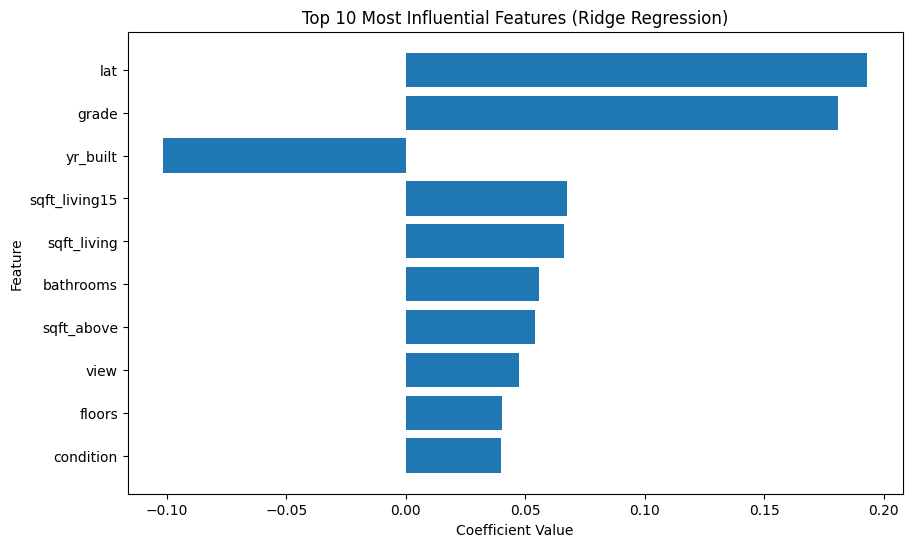

In [9]:
import matplotlib.pyplot as plt

# We already created coef_df_sorted in the previous step
# It contains features and their coefficients sorted by absolute importance

# Select top 10 most important features
top_features = coef_df_sorted.head(10)

# Create horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features (Ridge Regression)")

# Invert y-axis so the most important feature appears on top
plt.gca().invert_yaxis()

plt.savefig("../reports/figures/top_features_ridge.png", dpi=200, bbox_inches="tight")
plt.show()

### Interpretation of Feature Importance

The feature importacnce plot shows the variables that have the strongest influence on the predicted house prices in the Ridge regression model.

The most influential features are :

- **Latitude (lat)** - the strongest predictor, indicating that geografic location plays a major role in housing prices.
- **Grade** - representing the overall quality of the house construction and design.
- **Year built (yr_built)** - showing a negative relationship, meaning that older houses tend to have lower predicted prices.

Overall, the results suggest that **location and construction quality are the most important drivers of property value**.

Positive coefficients indicate that increasing the feature increases the predicted log price, while negative coefficients indicate and inverse relationship.

Because the features were standardized in the modeling pipeline, the coefficient magnitudes are directly comparable.

### 4.8 Final Summary

The model suggests that location (latitude) has a stronger influence on house prices than the living area of the property.

This aligns with real-world market behavior, where buyers often  prioritize location over size. A smaller property in a prime location can be more valuable than a larger one in a less desirable area.